In [1]:
import os
import cv2
import numpy as np

def load_images_labels(data_dir, image_size=(128, 128)):
    images = []
    labels = []
    class_names = sorted(os.listdir(data_dir))
    class_to_idx = {cls: idx for idx, cls in enumerate(class_names)}
    print("Class mapping:", class_to_idx)
    for cls in class_names:
        cls_folder = os.path.join(data_dir, cls)
        for file in os.listdir(cls_folder):
            img_path = os.path.join(cls_folder, file)
            img = cv2.imread(img_path)
            if img is None:
                continue
            img = cv2.resize(img, image_size)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            images.append(img)
            labels.append(class_to_idx[cls])
    return np.array(images), np.array(labels), class_names

data_folder = r'C:\Users\Lenovo\Downloads\satellite\data'
images, labels, class_names = load_images_labels(data_folder)
print("Total images:", len(images))


Class mapping: {'cloudy': 0, 'desert': 1, 'green_area': 2, 'water': 3}
Total images: 5631


In [7]:
from skimage.feature import hog
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import pandas as pd
from sklearn.metrics import classification_report

def extract_hog_features(images):
    features = []
    for img in images:
        hog_feat = hog(img,
                       orientations=9,
                       pixels_per_cell=(8, 8),
                       cells_per_block=(2, 2),
                       block_norm='L2-Hys')
        features.append(hog_feat)
    return np.array(features)

hog_features = extract_hog_features(images)

X_train, X_test, y_train, y_test = train_test_split(hog_features, labels, test_size=0.2, random_state=42, stratify=labels)

models = {
    "Naive Bayes": GaussianNB(),
    "SVM": SVC(kernel='linear'),
    "Decision Tree": DecisionTreeClassifier(random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    print(f"\n{name}:")
    print(f"Accuracy: {acc}")
    print(classification_report(y_test, preds, target_names=class_names))


Naive Bayes:
Accuracy: 0.7622005323868678
              precision    recall  f1-score   support

      cloudy       0.67      0.44      0.53       300
      desert       0.72      0.96      0.82       227
  green_area       0.80      0.84      0.82       300
       water       0.83      0.86      0.84       300

    accuracy                           0.76      1127
   macro avg       0.75      0.77      0.75      1127
weighted avg       0.76      0.76      0.75      1127


SVM:
Accuracy: 0.9591836734693877
              precision    recall  f1-score   support

      cloudy       0.93      0.95      0.94       300
      desert       0.95      0.96      0.96       227
  green_area       0.97      0.95      0.96       300
       water       0.98      0.98      0.98       300

    accuracy                           0.96      1127
   macro avg       0.96      0.96      0.96      1127
weighted avg       0.96      0.96      0.96      1127


Decision Tree:
Accuracy: 0.6832298136645962
       

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
def extract_sift_features(images):
    sift = cv2.SIFT_create()
    features = []
    for img in images:
        keypoints, descriptor = sift.detectAndCompute(img, None)
        if descriptor is None:
            descriptor = np.zeros((1, 128))
        features.append(descriptor.flatten())
    max_len = max(len(f) for f in features)
    features_padded = [np.pad(f, (0, max_len - len(f))) for f in features]
    return np.array(features_padded)

sift_features = extract_sift_features(images)

X_train, X_test, y_train, y_test = train_test_split(sift_features, labels, test_size=0.2, random_state=42, stratify=labels)

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)
preds = model.predict(X_test)
acc = accuracy_score(y_test, preds)
print(f"Decision Tree:")
print(f"Accuracy: {acc}")
print(classification_report(y_test, preds, target_names=class_names))

Decision Tree:
Accuracy: 0.3362910381543922
              precision    recall  f1-score   support

      cloudy       0.72      0.20      0.32       300
      desert       0.44      0.08      0.14       227
  green_area       0.50      0.10      0.16       300
       water       0.29      0.90      0.44       300

    accuracy                           0.34      1127
   macro avg       0.49      0.32      0.26      1127
weighted avg       0.49      0.34      0.27      1127



In [5]:
pip install opencv-contrib-python


Note: you may need to restart the kernel to use updated packages.


ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'C:\\Users\\Lenovo\\AppData\\Local\\Programs\\Python\\Python310\\Lib\\site-packages\\cv2\\cv2.pyd'
Consider using the `--user` option or check the permissions.

You should consider upgrading via the 'C:\Users\Lenovo\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [3]:
from skimage.feature import local_binary_pattern
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

def extract_lbp_features(images, P=8, R=1):
    features = []
    for img in images:
        lbp = local_binary_pattern(img, P, R, method='uniform')
        (hist, _) = np.histogram(lbp.ravel(),
                                 bins=np.arange(0, P + 3),
                                 range=(0, P + 2))
        hist = hist.astype("float")
        hist /= (hist.sum() + 1e-7)
        features.append(hist)
    return np.array(features)

lbp_features = extract_lbp_features(images)

X_train, X_test, y_train, y_test = train_test_split(lbp_features, labels, test_size=0.2, random_state=42, stratify=labels)

models = {
    "Naive Bayes": GaussianNB(),
    "SVM": SVC(kernel='linear'),
    "Decision Tree": DecisionTreeClassifier(random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    print(f"\n{name}:")
    print(f"Accuracy: {acc}")
    print(classification_report(y_test, preds, target_names=class_names))



Naive Bayes:
Accuracy: 0.906832298136646
              precision    recall  f1-score   support

      cloudy       0.96      0.71      0.82       300
      desert       0.83      0.99      0.90       227
  green_area       0.95      0.99      0.97       300
       water       0.90      0.96      0.93       300

    accuracy                           0.91      1127
   macro avg       0.91      0.91      0.90      1127
weighted avg       0.91      0.91      0.90      1127


SVM:
Accuracy: 0.8731144631765749
              precision    recall  f1-score   support

      cloudy       0.97      0.62      0.76       300
      desert       0.86      0.98      0.92       227
  green_area       0.86      0.98      0.92       300
       water       0.84      0.94      0.89       300

    accuracy                           0.87      1127
   macro avg       0.88      0.88      0.87      1127
weighted avg       0.88      0.87      0.87      1127


Decision Tree:
Accuracy: 0.968944099378882
         

In [8]:

X_train, X_test, y_train, y_test = train_test_split(hog_features, labels, test_size=0.2, random_state=42, stratify=labels)

dt_unreg = DecisionTreeClassifier(random_state=42)
dt_unreg.fit(X_train, y_train)
preds_unreg = dt_unreg.predict(X_test)
acc_unreg = accuracy_score(y_test, preds_unreg)
print("Unregularized Decision Tree:")
print(f"Accuracy: {acc_unreg}")
print(classification_report(y_test, preds_unreg, target_names=class_names))


dt_reg = DecisionTreeClassifier(random_state=42, max_depth=10, min_samples_leaf=5)
dt_reg.fit(X_train, y_train)
preds_reg = dt_reg.predict(X_test)
acc_reg = accuracy_score(y_test, preds_reg)
print("\n Regularized Decision Tree:")
print(f"Accuracy: {acc_reg}")
print(classification_report(y_test, preds_reg, target_names=class_names))


Unregularized Decision Tree:
Accuracy: 0.6832298136645962
              precision    recall  f1-score   support

      cloudy       0.55      0.59      0.57       300
      desert       0.66      0.65      0.65       227
  green_area       0.71      0.67      0.69       300
       water       0.83      0.81      0.82       300

    accuracy                           0.68      1127
   macro avg       0.69      0.68      0.68      1127
weighted avg       0.69      0.68      0.68      1127


 Regularized Decision Tree:
Accuracy: 0.6690328305235137
              precision    recall  f1-score   support

      cloudy       0.53      0.55      0.54       300
      desert       0.61      0.63      0.62       227
  green_area       0.69      0.69      0.69       300
       water       0.86      0.79      0.82       300

    accuracy                           0.67      1127
   macro avg       0.67      0.67      0.67      1127
weighted avg       0.68      0.67      0.67      1127



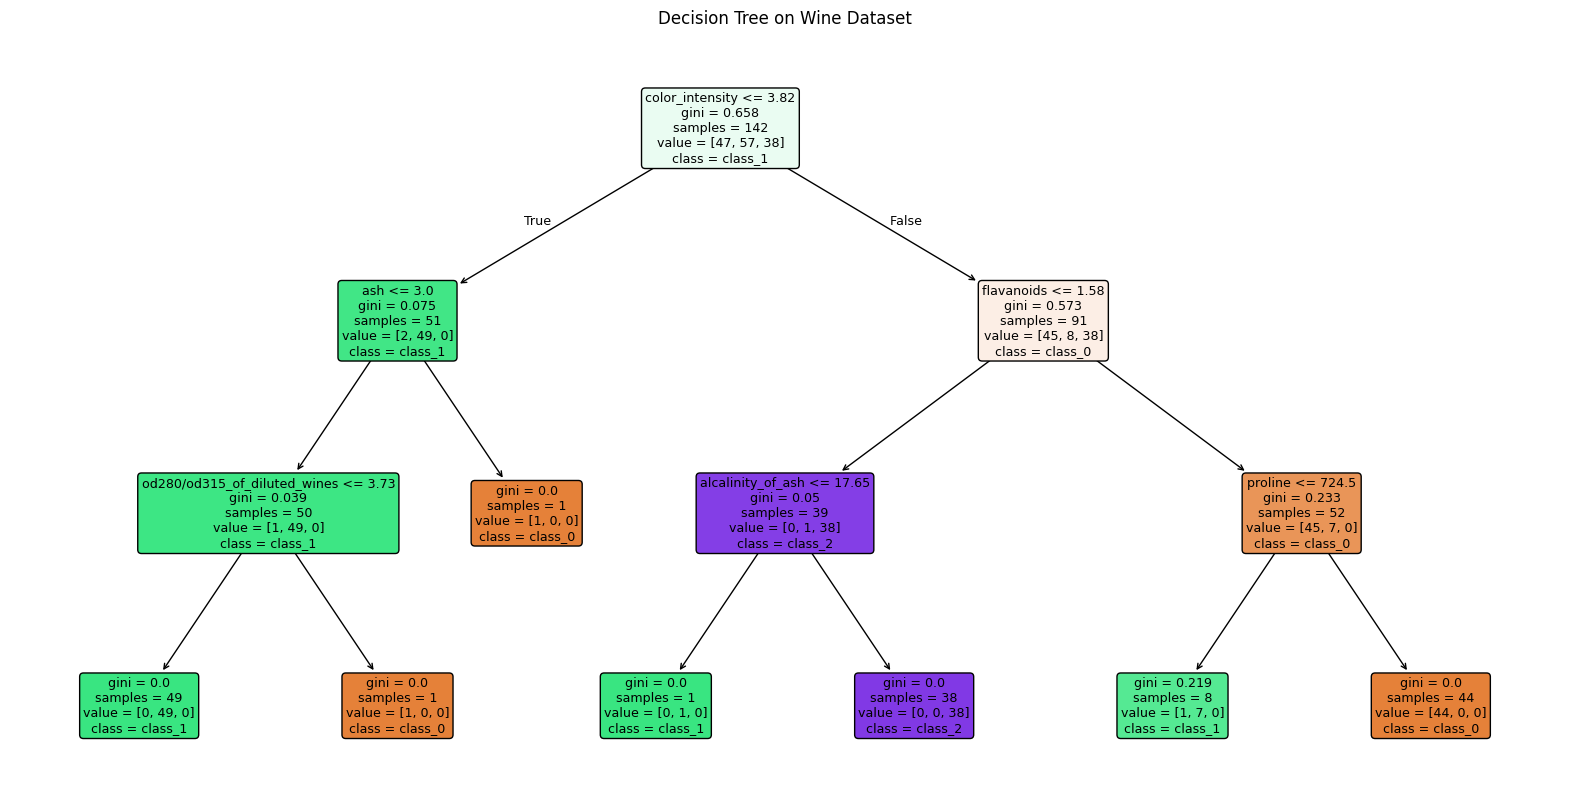

In [9]:
from sklearn.datasets import load_wine
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

data = load_wine()
X, y = data.data, data.target
feature_names = data.feature_names
class_names = data.target_names

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X_train, y_train)

plt.figure(figsize=(20, 10))
plot_tree(clf, filled=True, feature_names=feature_names, class_names=class_names, rounded=True)
plt.title("Decision Tree on Wine Dataset")
plt.show()
